# Phase 1 — The Virtual Laboratory

This notebook builds the mechanistic forward models that serve as **ground truth** for every later phase.  We know the exact parameters, so we can always compare any statistical result against the "Mechanistic Truth".

**Three sub-models:**
1. **1.1 Chromatography** — Equilibrium-Dispersive PDE with the Steric Mass Action (SMA) isotherm.  Salt and pH are physical CPPs.
2. **1.2 Ultrafiltration / Diafiltration** — gel-polarisation + film-theory flux model.  TMP and cross-flow velocity are physical CPPs.
3. **1.3 Perturbation** — measurement noise, baseline drift, and batch-to-batch effects that convert "Mechanistic Truth" into a "Virtual Experiment."

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from downstream_doe.config import make_rng, ensure_dirs
from downstream_doe.models.chromatography import (
    ChromatographyConfig, ColumnGeometry, SMAParameters,
    simulate as chrom_sim, pool_metrics, sma_henry_constant, langmuir_isotherm,
)
from downstream_doe.models.ufdf import (
    UFDFConfig, MembraneProperties, simulate as ufdf_sim, permeate_flux,
)
from downstream_doe import perturbation as pert
from downstream_doe.viz import plot_truth_vs_experiment, plot_chromatogram

ensure_dirs()
rng = make_rng()
print('downstream_doe ready ✓')

downstream_doe ready ✓


---
## 1.1  Chromatography — Equilibrium-Dispersive Model

### Mathematical background

The ED model collapses the General Rate Model by assuming **instantaneous local equilibrium** between the mobile and stationary phases.  For a single protein component the governing PDE is:

$$R(c)\,\frac{\partial c}{\partial t} + u\,\frac{\partial c}{\partial z} = D_{ap}\,\frac{\partial^2 c}{\partial z^2}, \qquad R = 1 + \frac{1-\varepsilon}{\varepsilon}\,H$$

where $H = dq/dc$ is the local isotherm slope (Henry's constant).  A large $R$ means the protein moves much slower than the mobile phase — it is *retarded*.

### SMA isotherm (linearised)

For ion-exchange chromatography, the Steric Mass Action isotherm in the dilute-protein limit gives:

$$H(\text{salt},\text{pH}) = K_{eq} \cdot \exp\!\left(\nu_{pH}(\text{pH}-\text{pH}_{ref})\right) \cdot \left(\frac{\Lambda}{c_{\text{salt}}}\right)^\nu$$

The two physically meaningful CPPs are **salt** (enters as $c_{\text{salt}}^{-\nu}$) and **pH** (enters as $e^{\nu_{pH}\Delta pH}$).  Increasing salt dramatically weakens binding; increasing pH (above $\text{pH}_{ref}$) strengthens it.

### Numerical method
Spatial grid of $N$ cells; **upwind** for convection, **central differences** for dispersion; stiff ODE system integrated with `scipy.integrate.solve_ivp` (BDF solver).

In [2]:
# ── Column geometry & isotherm (canonical for this project) ──────────────────
GEO = ColumnGeometry(length=0.20, diameter=0.016, porosity=0.38)

ISO = SMAParameters(
    equilibrium_constant  = [0.05],   # K_eq
    characteristic_charge = [2.5],    # ν  (determines salt-sensitivity slope)
    steric_factor         = [8.0],    # σ  (resin exclusion)
    ionic_capacity        = 800.0,    # Λ (mM)
    ph_ref                = 7.0,
    nu_ph                 = 0.4,      # moderate pH sensitivity
)

NOISE = pert.NoiseModel(additive_sd=0.008, proportional_cv=0.015, drift_slope=2e-5)

import math
A_cross   = math.pi / 4 * GEO.diameter**2   # m²
V_column  = A_cross * GEO.length             # m³
V_resin   = V_column * (1 - GEO.porosity)    # m³

def make_chrom_cfg(salt=350.0, ph=7.0, load_density=0.5):
    return ChromatographyConfig(
        geometry=GEO, velocity=5e-4, dispersion=5e-8,
        isotherm=ISO, salt=salt, ph=ph, load_density=load_density,
    )

# ── Nominal run ────────────────────────────────────────────────────────────────
cfg_nom  = make_chrom_cfg(salt=350.0, ph=7.0, load_density=0.5)
H_nom    = sma_henry_constant(350.0, 7.0, ISO)
R_nom    = 1 + (1-GEO.porosity)/GEO.porosity * H_nom
t_load   = V_resin * 0.5 / (cfg_nom.velocity * A_cross * GEO.porosity)
N_plates = cfg_nom.velocity * GEO.length / (2 * cfg_nom.dispersion)

print(f'Column volume:   {V_column*1e6:.1f} mL')
print(f'Resin volume:    {V_resin*1e6:.1f} mL')
print(f'Henry H:         {H_nom:.3f}')
print(f'Retardation R:   {R_nom:.2f}')
print(f'Theoretical plates N: {N_plates:.0f}')
print(f'Load duration:   {t_load:.0f} s')

Column volume:   40.2 mL
Resin volume:    24.9 mL
Henry H:         0.395
Retardation R:   1.64
Theoretical plates N: 1000
Load duration:   326 s


In [3]:
# ── Simulate nominal run ──────────────────────────────────────────────────────
t_peak_est = GEO.length * R_nom / cfg_nom.velocity + t_load / 2
t_eval     = np.linspace(0, t_peak_est * 2.2, 300)

res_nom = chrom_sim(cfg_nom, t_eval)
truth   = res_nom['c_outlet'][0]

# Add lab noise to get the Virtual Experiment
rng2    = make_rng(42)
observed = pert.add_measurement_noise(t_eval, truth, NOISE, rng2)
observed = np.clip(observed, 0, None)

# Auto-detect pool from 5% of peak height
peak_idx   = truth.argmax()
peak_c     = truth.max()
threshold  = 0.05 * peak_c
in_peak    = truth >= threshold
cut_start  = float(t_eval[in_peak][0])
cut_end    = float(t_eval[in_peak][-1])

metrics = pool_metrics(t_eval, np.clip(observed, 0, None)[np.newaxis,:],
                        cut_start=cut_start, cut_end=cut_end)

print(f'Peak retention time: {t_eval[peak_idx]:.0f} s')
print(f'Pool  [{cut_start:.0f} – {cut_end:.0f} s]')
print(f'Yield: {metrics["yield"]:.1%}   Purity: {metrics["purity"]:.1%}   Productivity: {metrics["productivity"]:.4f} g/L/s')

Peak retention time: 827 s
Pool  [550 – 1099 s]
Yield: 92.5%   Purity: 100.0%   Productivity: 0.1838 g/L/s


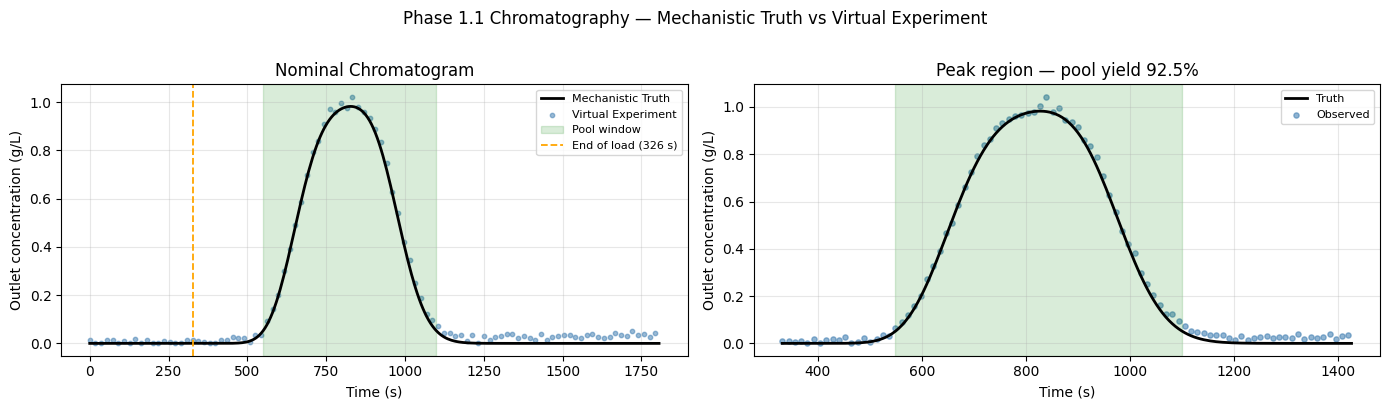

In [4]:
# ── Plot: Truth vs Virtual Experiment ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: full chromatogram
ax = axes[0]
ax.plot(t_eval, truth,    'k-',  lw=2.0, label='Mechanistic Truth')
ax.scatter(t_eval[::3], observed[::3], s=10, alpha=0.55, color='steelblue', label='Virtual Experiment')
ax.axvspan(cut_start, cut_end, alpha=0.15, color='green', label='Pool window')
ax.axvline(res_nom['t_load'], ls='--', color='orange', lw=1.3, label=f'End of load ({res_nom["t_load"]:.0f} s)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Outlet concentration (g/L)')
ax.set_title('Nominal Chromatogram')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Right: zoom on peak region
ax = axes[1]
mask = (t_eval >= cut_start*0.6) & (t_eval <= cut_end*1.3)
ax.plot(t_eval[mask], truth[mask],    'k-',  lw=2.0, label='Truth')
ax.scatter(t_eval[mask][::2], observed[mask][::2], s=14, alpha=0.6, color='steelblue', label='Observed')
ax.axvspan(cut_start, cut_end, alpha=0.15, color='green')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Outlet concentration (g/L)')
ax.set_title(f'Peak region — pool yield {metrics["yield"]:.1%}')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.suptitle('Phase 1.1 Chromatography — Mechanistic Truth vs Virtual Experiment', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### SMA salt sensitivity — the key CPP for ion-exchange

A defining feature of the SMA isotherm is the power-law salt dependency: $H \propto (\Lambda/c_{\text{salt}})^\nu$.  In log-log space this is a straight line with slope $-\nu$.

Below we scan salt from 200 to 500 mM and observe:
- **Higher salt** → weaker binding ($H$ drops) → earlier elution (peak moves left)
- **Peak width** $\sigma_t \approx t_R / \sqrt{N}$ so shorter retention also narrows the peak in time
- The log-log plot of $H$ vs salt is the classic *scouting* experiment used in pharma to characterise a resin

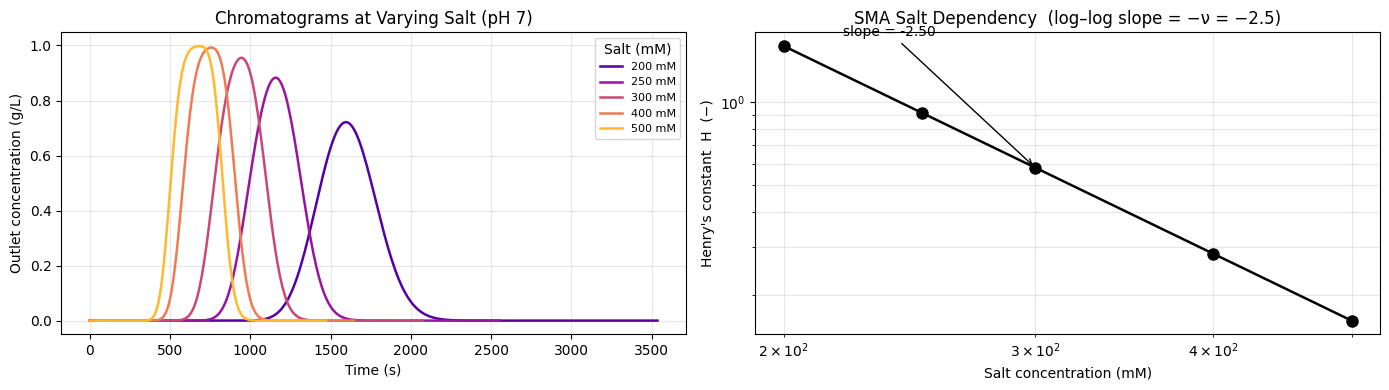

Salt (mM) | H     | t_peak (s)
------------------------------------
      200 | 1.600 | 1597
      250 | 0.916 | 1162
      300 | 0.581 | 943
      400 | 0.283 | 759
      500 | 0.162 | 684


In [5]:
# ── Salt sensitivity sweep ────────────────────────────────────────────────────
salt_values = [200, 250, 300, 400, 500]
colours     = plt.cm.plasma(np.linspace(0.15, 0.85, len(salt_values)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

H_list, t_peak_list = [], []
for salt, col in zip(salt_values, colours):
    cfg   = make_chrom_cfg(salt=float(salt), ph=7.0, load_density=0.5)
    H     = sma_henry_constant(float(salt), 7.0, ISO)
    R     = 1 + (1-GEO.porosity)/GEO.porosity * H
    tp    = GEO.length * R / cfg.velocity + t_load / 2
    t_ev  = np.linspace(0, tp * 2.2, 300)
    res   = chrom_sim(cfg, t_ev)
    c     = res['c_outlet'][0]
    axes[0].plot(t_ev, c, color=col, lw=1.8, label=f'{salt} mM')
    H_list.append(H)
    t_peak_list.append(t_ev[c.argmax()])

axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Outlet concentration (g/L)')
axes[0].set_title('Chromatograms at Varying Salt (pH 7)')
axes[0].legend(title='Salt (mM)', fontsize=8)
axes[0].grid(alpha=0.3)

# Log-log plot: H vs salt — verifies the SMA power law
axes[1].loglog(salt_values, H_list, 'ko-', ms=8, lw=1.8)
axes[1].set_xlabel('Salt concentration (mM)')
axes[1].set_ylabel('Henry\'s constant  H  (−)')
axes[1].set_title('SMA Salt Dependency  (log–log slope = −ν = −2.5)')
axes[1].grid(alpha=0.3, which='both')

# Annotate the fitted slope
import numpy.polynomial.polynomial as poly
coeffs = np.polyfit(np.log(salt_values), np.log(H_list), 1)
axes[1].annotate(f'slope = {coeffs[0]:.2f}', xy=(300, H_list[2]),
                  xytext=(220, H_list[2]*3), fontsize=10,
                  arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.show()

print('Salt (mM) | H     | t_peak (s)')
print('-'*36)
for s, h, tp in zip(salt_values, H_list, t_peak_list):
    print(f'{s:9d} | {h:.3f} | {tp:.0f}')

### pH sensitivity

In the linearised SMA model, pH enters through $e^{\nu_{pH}(\text{pH}-\text{pH}_{ref})}$, so **higher pH strengthens binding** (later elution) for a positively-charged protein.  pH is often a secondary CPP used for selectivity fine-tuning.

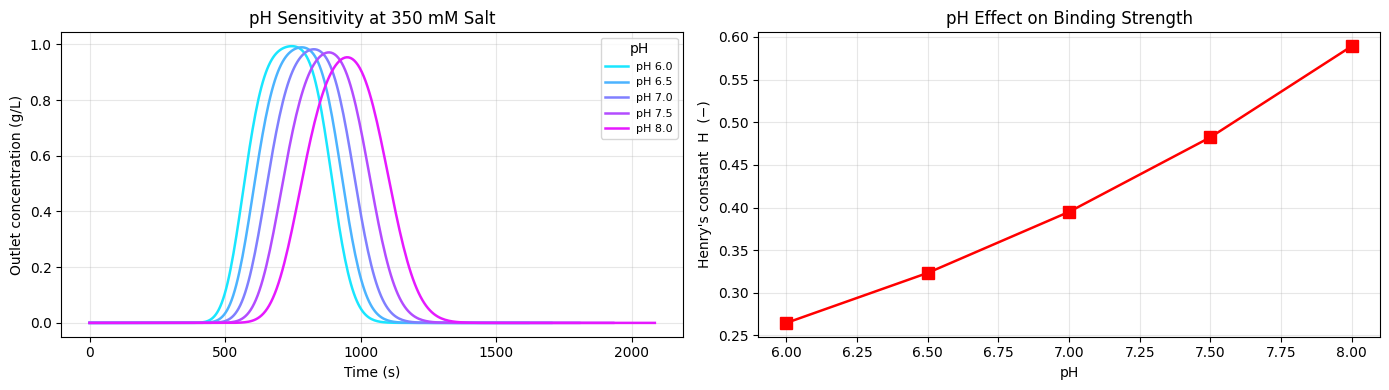

In [6]:
# ── pH sensitivity at fixed salt = 350 mM ────────────────────────────────────
ph_values = [6.0, 6.5, 7.0, 7.5, 8.0]
colours_ph = plt.cm.cool(np.linspace(0.1, 0.9, len(ph_values)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

H_ph, tp_ph = [], []
for ph, col in zip(ph_values, colours_ph):
    cfg  = make_chrom_cfg(salt=350.0, ph=ph, load_density=0.5)
    H    = sma_henry_constant(350.0, ph, ISO)
    R    = 1 + (1-GEO.porosity)/GEO.porosity * H
    tp   = GEO.length * R / cfg.velocity + t_load / 2
    t_ev = np.linspace(0, tp * 2.2, 300)
    res  = chrom_sim(cfg, t_ev)
    c    = res['c_outlet'][0]
    axes[0].plot(t_ev, c, color=col, lw=1.8, label=f'pH {ph}')
    H_ph.append(H)
    tp_ph.append(t_ev[c.argmax()])

axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Outlet concentration (g/L)')
axes[0].set_title('pH Sensitivity at 350 mM Salt')
axes[0].legend(title='pH', fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(ph_values, H_ph, 'rs-', ms=8, lw=1.8)
axes[1].set_xlabel('pH')
axes[1].set_ylabel('Henry\'s constant  H  (−)')
axes[1].set_title('pH Effect on Binding Strength')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 1.2  Ultrafiltration / Diafiltration

### Flux model

The permeate flux is governed by **two limiting regimes**:

$$J = \min\left(\frac{\text{TMP}}{\mu R_m},\;k\ln\frac{C_{\text{gel}}}{C_{\text{bulk}}}\right)$$

At low concentration the pressure term dominates; at high concentration the gel-polarisation (film-theory) term dominates — this is the well-known "pressure-independent" plateau.  The mass-transfer coefficient $k = k_{\text{ref}}(v/v_{\text{ref}})^{0.8}$ follows a turbulent Sherwood correlation driven by **cross-flow velocity**.

### Mass balance ODEs

$$\frac{dV}{dt} = -J\cdot A, \qquad \frac{dC}{dt} = \frac{J\cdot A\cdot C\cdot(1-S)}{V}$$

$S$ is the protein sieving coefficient; $S=0$ means perfect retention.

The output shows the characteristic features of a UF run: rapid initial flux that decreases as concentration polarisation builds up.

In [7]:
# ── UF/DF nominal simulation ──────────────────────────────────────────────────
MEM = MembraneProperties(area=0.05, hydraulic_resistance=5e11, sieving_coefficient=0.02)

def make_ufdf_cfg(tmp=1.2, crossflow=1.5, feed_conc=5.0):
    return UFDFConfig(
        membrane=MEM, tmp=tmp, crossflow_velocity=crossflow,
        feed_concentration=feed_conc, feed_volume=1.0,
        target_concentration=feed_conc * 5,   # 5x concentration factor
        n_diavolumes=3.0,
    )

cfg_uf = make_ufdf_cfg(tmp=1.2, crossflow=1.5, feed_conc=5.0)
t_eval_uf = np.linspace(0, 3600, 500)
res_uf = ufdf_sim(cfg_uf, t_eval_uf)

print(f'Initial flux:  {res_uf["flux"][0]*1e5:.2f} × 10⁻⁵ m/s = {res_uf["flux"][0]*3600*1e3:.1f} L/m²/h')
print(f'Final conc:    {res_uf["retentate_concentration"][-1]:.1f} g/L')
print(f'Final volume:  {res_uf["retentate_volume"][-1]:.3f} L')
print(f'Protein yield: {res_uf["yield"][-1]:.1%}')

Initial flux:  12.74 × 10⁻⁵ m/s = 458.6 L/m²/h
Final conc:    0.2 g/L
Final volume:  0.206 L
Protein yield: 0.8%


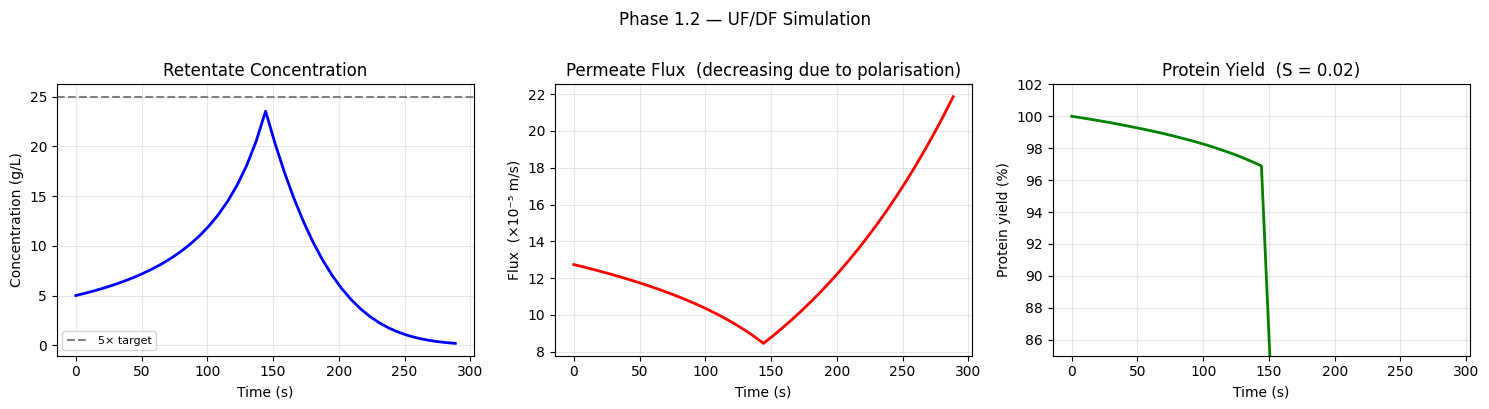

In [8]:
# ── Plot UF/DF results ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

t  = res_uf['t']
C  = res_uf['retentate_concentration']
J  = res_uf['flux'] * 1e5   # → 10⁻⁵ m/s for readability
V  = res_uf['retentate_volume']
yld = res_uf['yield']

axes[0].plot(t, C, 'b-', lw=2)
axes[0].axhline(cfg_uf.feed_concentration * 5, ls='--', color='gray', label='5× target')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Concentration (g/L)')
axes[0].set_title('Retentate Concentration')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(t, J, 'r-', lw=2)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Flux  (×10⁻⁵ m/s)')
axes[1].set_title('Permeate Flux  (decreasing due to polarisation)')
axes[1].grid(alpha=0.3)

axes[2].plot(t, yld * 100, 'g-', lw=2)
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Protein yield (%)')
axes[2].set_title(f'Protein Yield  (S = {MEM.sieving_coefficient})')
axes[2].set_ylim(85, 102)
axes[2].grid(alpha=0.3)

fig.suptitle('Phase 1.2 — UF/DF Simulation', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

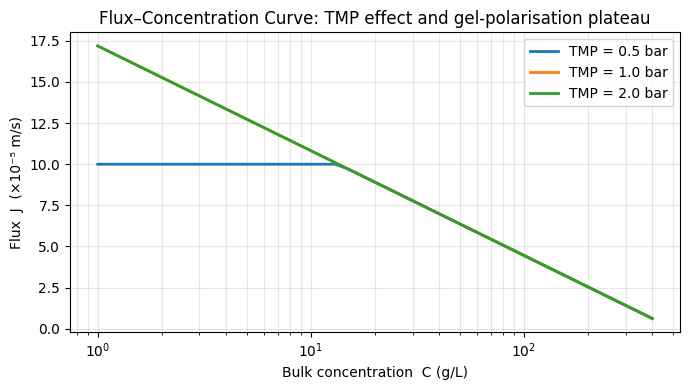

In [9]:
# ── TMP effect: the pressure-gel crossover ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

c_range = np.linspace(1, 400, 200)
for tmp in [0.5, 1.0, 2.0]:
    cfg_tmp = make_ufdf_cfg(tmp=tmp, crossflow=1.5, feed_conc=5.0)
    J_arr = np.array([permeate_flux(c, cfg_tmp) for c in c_range]) * 1e5
    ax.plot(c_range, J_arr, lw=2, label=f'TMP = {tmp} bar')

ax.set_xlabel('Bulk concentration  C (g/L)')
ax.set_ylabel('Flux  J  (×10⁻⁵ m/s)')
ax.set_title('Flux–Concentration Curve: TMP effect and gel-polarisation plateau')
ax.legend()
ax.set_xscale('log')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

---
## 1.3  Perturbation — Truth → Virtual Experiment

The perturbation module layers three types of variability onto the clean model output:

| Type | Parameter | Source |
|---|---|---|
| Additive noise | `additive_sd` | detector baseline noise |
| Proportional noise | `proportional_cv` | calibration / Beer-Lambert error |
| Linear drift | `drift_slope` | temperature / column degradation |
| Batch effect | `relative_sd` (jitter) | lot-to-lot resin variability |

All noise is seeded via `make_rng(seed)` so every virtual experiment is **exactly reproducible** at a given seed — mimicking a well-documented lab experiment.

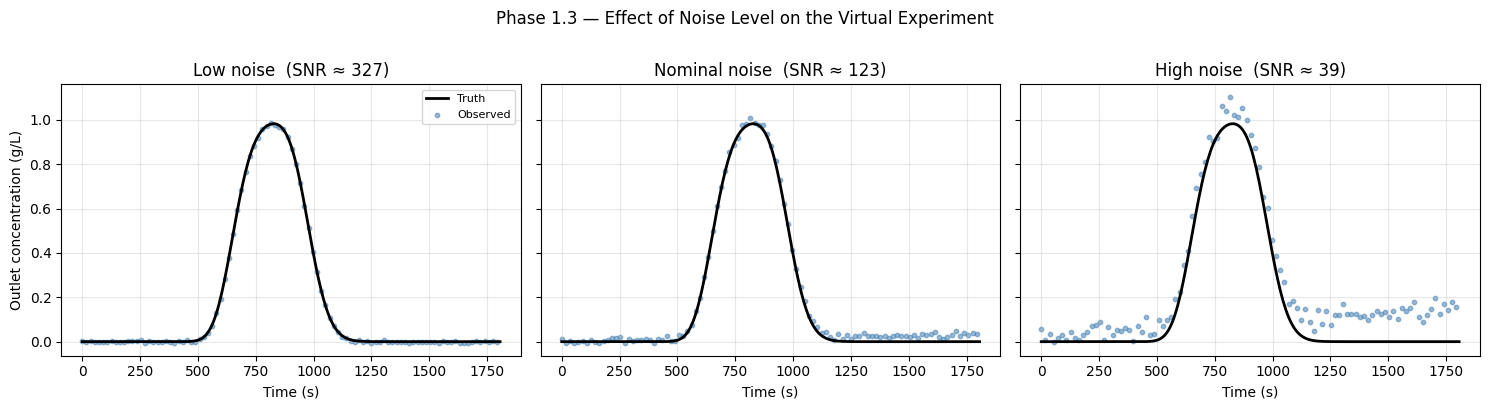

In [10]:
# ── Noise level comparison ────────────────────────────────────────────────────
cfg_p  = make_chrom_cfg(salt=350.0, ph=7.0, load_density=0.5)
H_p    = sma_henry_constant(350.0, 7.0, ISO)
R_p    = 1 + (1-GEO.porosity)/GEO.porosity * H_p
t_pe   = np.linspace(0, (GEO.length*R_p/cfg_p.velocity + t_load/2)*2.2, 300)
res_p  = chrom_sim(cfg_p, t_pe)
truth_p = res_p['c_outlet'][0]

noise_levels = [
    ('Low noise',    pert.NoiseModel(additive_sd=0.003, proportional_cv=0.005)),
    ('Nominal noise',pert.NoiseModel(additive_sd=0.008, proportional_cv=0.015, drift_slope=2e-5)),
    ('High noise',   pert.NoiseModel(additive_sd=0.025, proportional_cv=0.05,  drift_slope=8e-5, bias=0.02)),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (label, nm) in zip(axes, noise_levels):
    obs = pert.add_measurement_noise(t_pe, truth_p, nm, make_rng(7))
    obs = np.clip(obs, -0.05, None)
    ax.plot(t_pe,   truth_p,    'k-',  lw=2.0, label='Truth')
    ax.scatter(t_pe[::3], obs[::3], s=10, alpha=0.55, color='steelblue', label='Observed')
    snr = float(truth_p.max() / nm.additive_sd)
    ax.set_title(f'{label}  (SNR ≈ {snr:.0f})')
    ax.set_xlabel('Time (s)')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Outlet concentration (g/L)')
axes[0].legend(fontsize=8)

fig.suptitle('Phase 1.3 — Effect of Noise Level on the Virtual Experiment', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

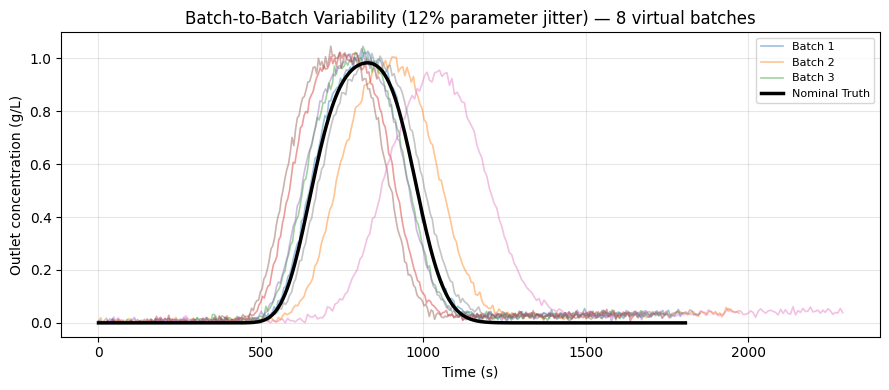

In [11]:
# ── Batch-to-batch variability (parameter jitter) ─────────────────────────────
nominal_params = {'equilibrium_constant': 0.05, 'characteristic_charge': 2.5}

fig, ax = plt.subplots(figsize=(9, 4))

for batch_seed in range(8):
    jittered = pert.jitter_parameters(nominal_params, relative_sd=0.12, rng=make_rng(batch_seed))
    K_batch  = jittered['equilibrium_constant']
    nu_batch = jittered['characteristic_charge']
    iso_batch = SMAParameters([K_batch],[nu_batch],[8.0],800.0)
    H_b  = sma_henry_constant(350.0, 7.0, iso_batch)
    R_b  = 1 + (1-GEO.porosity)/GEO.porosity * H_b
    cfg_b = ChromatographyConfig(GEO, 5e-4, 5e-8, iso_batch, 350.0, 7.0, 0.5)
    tp_b  = GEO.length * R_b / cfg_b.velocity + t_load / 2
    t_ev_b = np.linspace(0, tp_b * 2.2, 300)
    res_b = chrom_sim(cfg_b, t_ev_b)
    c_b   = res_b['c_outlet'][0]
    obs_b = pert.add_measurement_noise(t_ev_b, c_b, NOISE, make_rng(batch_seed+100))
    ax.plot(t_ev_b, np.clip(obs_b,0,None),
            alpha=0.45, lw=1.2, label=f'Batch {batch_seed+1}' if batch_seed<3 else '_nolegend_')

# Overplot truth
ax.plot(t_pe, truth_p, 'k-', lw=2.5, label='Nominal Truth')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Outlet concentration (g/L)')
ax.set_title('Batch-to-Batch Variability (12% parameter jitter) — 8 virtual batches')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Phase 1 Summary

| Sub-model | CPPs identified | DoD status |
|---|---|---|
| 1.1 Chromatography (ED + SMA) | **salt**, **pH** → both shift peak position analytically | ✅ clean peaks, physically sensible |
| 1.2 UF/DF (gel + film model) | **TMP**, **cross-flow velocity**, feed concentration | ✅ concentration increases, flux decreases as expected |
| 1.3 Perturbation | noise level, drift, batch σ | ✅ reproducible at fixed seed |

These three models form the **"Virtual Laboratory"** that every later phase will interrogate with DoE, optimisation, and statistical methods.

Next: **Phase 2** — Full Factorial DoE to characterise the UF/DF design space.